# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Becca Hobson

**Date:** 9/2/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.

In [10]:
# Problem 1.1
import pandas as pd
airbnb_df = pd.read_csv('/content/airbnb_hw.csv')

#Investiagte Data
print("airbnb_df.shape:")
print(airbnb_df.shape, '\n') #looking at size of data frame
airbnb_df['Price'].head(20)
airbnb_df['Price'].sort_values() #need to strip data
airbnb_df['Price'].dtype #currently object data type, need to transform to integer

#Strip Data
airbnb_df['Price'] = airbnb_df['Price'].str.replace("$", "", regex=False)
airbnb_df['Price'] = airbnb_df['Price'].str.replace(",", "", regex=False) #stripped of $ and ,

#Convert Data
airbnb_df['Price'] = pd.to_numeric(airbnb_df['Price'], errors = "coerce")
airbnb_df['Price'].dtype #confirming that dtype is now int64

#Re-investigate Data
airbnb_df['Price'].head(20)
airbnb_df['Price'].sort_values()
print("Final Missing Values", airbnb_df['Price'].isna().sum()) #checking if data is cleaned sufficently


airbnb_df.shape:
(30478, 13) 

Final Missing Values 0


In [74]:
#Problem 1.2
import pandas as pd
police_df = pd.read_csv('/content/mn_police_use_of_force.csv')

#Investiagte Data
print("police_df.shape:")
print(police_df.shape, '\n') #looking at size of data frame
police_df['subject_injury'].head(20)
print("Total Values",police_df['subject_injury'].value_counts(dropna=False)) #need to address NaN

#Clean Data
police_df['subject_injury'] = police_df['subject_injury'].astype(str) #convert to string
police_df['subject_injury'] = police_df['subject_injury'].str.strip() #remove excess spaces
police_df['subject_injury'] = police_df['subject_injury'].str.lower() #convert to lower case
police_df['subject_injury'].head(20) #check
police_df['subject_injury'] = police_df['subject_injury'].replace({
    'none': pd.NA,
    'na': pd.NA,
    'nan': pd.NA,
    '': pd.NA,
    'unknown': pd.NA})
police_df['subject_injury'] = police_df['subject_injury'].replace({
    'yes': 'Yes',
    'y': 'Yes',
    'no': 'No',
    'n': 'No'})

#Find Missing Values
police_df['subject_injury'].value_counts(dropna=False)
print("\nMissing values", police_df['subject_injury'].isna().sum())
print("Proportion of Missing values as a %:", police_df['subject_injury'].isna().mean()*100)

#Cross Tabulate Data
pd.crosstab(
    police_df['force_type'],
    police_df['subject_injury'],
    dropna=False)

police_df.shape:
(12925, 13) 

Total Values subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64

Missing values 9848
Proportion of Missing values as a %: 76.19342359767892


subject_injury,No,Yes,NaN
force_type,,,
Baton,0,2,2
Bodily Force,1093,1286,7051
Chemical Irritant,131,41,1421
Firearm,2,0,0
Gun Point Display,33,44,27
Improvised Weapon,34,40,74
Less Lethal,0,0,87
Less Lethal Projectile,1,2,0
Maximal Restraint Technique,0,0,170


76.2% of the values are missing (9,848 out of 12,925). Yes, this is definitely a concern because more than three quarters of the data points are missing. This leaves very few data points that can be used to determine whether a person was injured. The misisng values are not evenly distrubuted across the rows, suggesting a pattern.

shark_df.shape:
(7117, 23) 

Missing values:
 Date                 0
Year                 2
Type                18
Country             50
State              487
Location           567
Activity           583
Name               218
Sex                578
Age               2994
Injury              36
Fatal Y/N          561
Time              3527
Species           3131
Source              20
pdf                318
href formula       323
href               321
Case Number        319
Case Number.1      320
original order     318
Unnamed: 21       7116
Unnamed: 22       7115
dtype: int64

Dropping: ['Unnamed: 21', 'Unnamed: 22']

New df Shape (7117, 21)
Missing Values: 0

    Decade  Mean Attacks Per Year
0    1940                  28.30
1    1950                  46.70
2    1960                  61.80
3    1970                  33.90
4    1980                  43.80
5    1990                  57.20
6    2000                 102.20
7    2010                 124.90
8    2020                  8

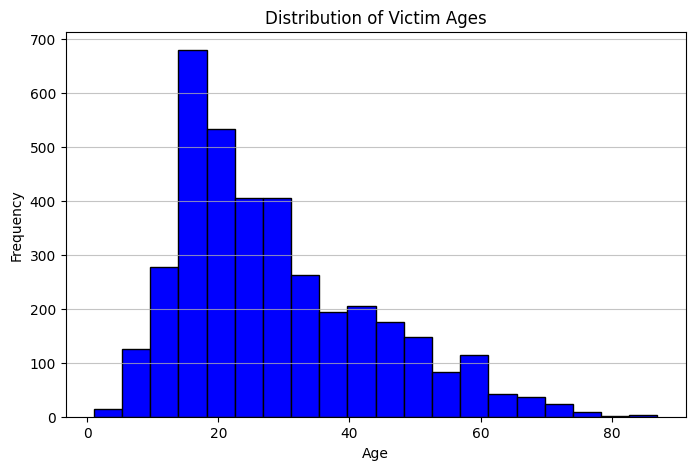

Missing Values: 0
Proportion of Male Victims as a %: 83.31104573415352

Type Value Counts:
 Type
Unprovoked    3101
Unknown        335
Provoked       303
Name: count, dtype: int64

Proportion of Unprovoked Attacks as a %: 82.94


In [169]:
#Problem 2
import pandas as pd
import matplotlib.pyplot as plt
shark_df = pd.read_excel('/content/GSAF5 (1).xls')

#Investiagte Data
print("shark_df.shape:")
print(shark_df.shape, '\n') #looking at size of data frame
shark_df.head(20)
print("Missing values:\n", shark_df.isna().sum())
shark_df.count()

#Drop Columns Not Containing Data
empty_cols = [c for c in shark_df.columns if shark_df[c].notna().sum() <= 2]
print("\nDropping:", empty_cols)
shark_df = shark_df.drop(columns=empty_cols)
print("\nNew df Shape", shark_df.shape)

#Clean Year Variable
shark_df['Year'].head(20) #needs to be stripped, dtype is float64
shark_df['Year'] = pd.to_numeric(shark_df['Year'], errors='coerce').astype('Int64') #converted dtype to Int64
shark_df = shark_df.dropna(subset=['Year'])
shark_df['Year'] = shark_df['Year'].astype(int)
print("Missing Values:", shark_df['Year'].isna().sum())
shark_df['Year'].sort_values() #range from 0 to 2026
shark_df = shark_df[(shark_df['Year'] > 1400)]
shark_df['Year'].sort_values() #removed impossible years

#Compare Number of Attacks Over the Years
shark_df = shark_df[(shark_df['Year'] > 1939)] #filter to focus on 1940 onwards
yearly_counts = shark_df.groupby('Year').size()
decade_means = yearly_counts.groupby(yearly_counts.index//10*10).mean().reset_index() #group yearly totals by decade
decade_means.columns = ['Decade', 'Mean Attacks Per Year']
decade_means['Mean Attacks Per Year'] = decade_means['Mean Attacks Per Year'].round(2) #round to 2 decimal places
print("\n", decade_means)

#Clean Age Variable
shark_df['Age'].head(20)
shark_df['Age'] = shark_df['Age'].astype(str).str.extract(r'(\d+)').astype(float)
shark_df = shark_df.dropna(subset=['Age']) #dropped NaN values
shark_df.sort_values(by = 'Age', ascending=False)
shark_df['Age'].sort_values()

#Make Histogram
plt.figure(figsize=(8, 5))
plt.hist(shark_df['Age'], bins=20, color='blue', edgecolor='black')
plt.title('Distribution of Victim Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

#Find Proportion of Male Victims
shark_df['Sex'] = shark_df['Sex'].astype(str).str.strip() #remove excess spaces
shark_df['Sex'] = shark_df['Sex'].astype(str).str.upper() #convert to uper case
print("Missing Values:", shark_df['Sex'].isna().sum())
male_proportion = (shark_df['Sex'] == 'M').sum()/len(shark_df)
print("Proportion of Male Victims as a %:", male_proportion * 100)

#Clean Type Variable & Calculate Proportion of Unprovoked Attacks
shark_df['Type'] = shark_df['Type'].astype(str).str.strip() #remove excess spaces
shark_df['Type'] = shark_df['Type'].astype(str).str.title() #convert to title case
def sort_type(val): # sort all entries into Provoked, Unprovoked, or Unknown
    if val == 'Provoked':
        return 'Provoked'
    elif val == 'Unprovoked':
        return 'Unprovoked'
    else:
        return 'Unknown'
shark_df['Type'] = shark_df['Type'].apply(sort_type)
unprovoked_proportion = (shark_df['Type'] == 'Unprovoked').sum() / len(shark_df) #calculate proportion of unprovoked attacks
print("\nType Value Counts:\n", shark_df['Type'].value_counts())
print("\nProportion of Unprovoked Attacks as a %:", round(unprovoked_proportion * 100, 2)) #round to 2 decimal places


The attacks have been increasing substantially over time since 1940. Approximately of 83% of all victims are male. Approximately 83% of attacks are unprovoked.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]